# Plot Original Scaling From Sampling Checkpoints

This notebook reads `NCC_original_sampling_r` checkpoints from `data/`, aggregates scaling data, and plots `expected_r_min` and `sampled_r_min` versus `N`, `T`, and `\epsilon`.

1-st order Ising PF: Gate count = $r_{min}(2*N*\kappa + \mathrm{truncation~order}+1)= r_{min}(2*N+ 4)$

In [22]:
import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

%config InlineBackend.figure_format = 'retina'
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({'font.size': 16})
plt.rcParams['text.usetex'] = True

SAVE_PDF = False
FIG_DIR = Path('figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path('data')
BASELINE = {'N': 4, 'T': 1.0, 'epsilon': 0.01, 'trials': 200, 'repeats': 3}
TARGETS = {
    'N': [4, 5, 6],
    'T': [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5],
    'inv_epsilon': [25.0, 100.0 / 3.0, 50.0, 100.0, 200.0, 400.0, 800.0, 1600.0],
}
THEORY_EXPONENTS = {'N': 5 / 3, 'T': 4 / 3, 'inv_epsilon': 1 / 3}

NAME_RE = re.compile(
    r'^NCC_original_sampling_r_N(?P<N>[^_]+)_T(?P<T>[^_]+)_eps(?P<epsilon>[^_]+)_trials(?P<trials>\d+)_repeats(?P<repeats>\d+)(?:_(?P<tag>.+))?$'
)


def parse_checkpoint(path):
    match = NAME_RE.match(path.stem)
    if match is None:
        return None
    meta = match.groupdict()
    payload = json.loads(path.read_text())
    sampled = np.array(payload['sampled_r_mins'], dtype=float)
    expected = np.array(payload['expected_r_mins'], dtype=float)
    if sampled.size <= 1:
        sampled_low = sampled_high = float(sampled.mean()) if sampled.size else float('nan')
    else:
        sampled_std = float(np.std(sampled, ddof=1))
        half_width = 1.96 * sampled_std / math.sqrt(sampled.size)
        sampled_low = float(sampled.mean() - half_width)
        sampled_high = float(sampled.mean() + half_width)
    return {
        'path': path,
        'N': int(meta['N']),
        'T': float(meta['T']),
        'epsilon': float(meta['epsilon']),
        'inv_epsilon': float(1.0 / float(meta['epsilon'])),
        'trials': int(meta['trials']),
        'repeats': int(meta['repeats']),
        'sampled_mean': float(sampled.mean()),
        'sampled_low': sampled_low,
        'sampled_high': sampled_high,
        'expected_mean': float(expected.mean()),
        'sampled_values': sampled,
        'expected_values': expected,
        'params': payload['params'],
    }


def load_records(data_dir=DATA_DIR):
    records = []
    for path in sorted(data_dir.glob('NCC_original_sampling_r_*.json')):
        record = parse_checkpoint(path)
        if record is None:
            continue
        records.append(record)
    if not records:
        raise FileNotFoundError(f'No original sampling checkpoints found in {data_dir}')
    return records


def build_axis_series(records, axis, baseline=BASELINE, targets=TARGETS):
    filtered = []
    for record in records:
        if record['trials'] != baseline['trials'] or record['repeats'] != baseline['repeats']:
            continue
        if axis != 'N' and record['N'] != baseline['N']:
            continue
        if axis != 'T' and not math.isclose(record['T'], baseline['T'], rel_tol=0.0, abs_tol=1e-12):
            continue
        if axis != 'inv_epsilon' and not math.isclose(record['epsilon'], baseline['epsilon'], rel_tol=0.0, abs_tol=1e-12):
            continue
        filtered.append(record)
    ordered = []
    for target in targets[axis]:
        for record in filtered:
            if math.isclose(float(record[axis]), float(target), rel_tol=0.0, abs_tol=1e-12):
                ordered.append(record)
                break
    return ordered


def fit_power_law(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    coeffs = np.polyfit(np.log(x), np.log(y), 1)
    slope = float(coeffs[0])
    prefactor = float(math.exp(coeffs[1]))
    return slope, prefactor


def scaled_reference(x, y0, x0, exponent):
    x = np.array(x, dtype=float)
    return y0 * (x / x0) ** exponent


def format_tick_labels(values):
    labels = []
    for value in np.array(values, dtype=float):
        if math.isclose(value, round(value), abs_tol=1e-12):
            labels.append(str(int(round(value))))
        else:
            labels.append(f'{value:.4f}'.rstrip('0').rstrip('.'))
    return labels


def plot_missing(ax, title, xlabel):
    ax.set_title(title, fontsize=20)
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel('min gate count', fontsize=18)
    ax.text(0.5, 0.5, 'data not collected', ha='center', va='center', fontsize=18, transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_alpha(0.3)


def plot_expected_panel(ax, records, axis, xlabel, title, theory_exp, invert_x=False):
    if len(records) == 0:
        plot_missing(ax, title, xlabel)
        return None
    x = np.array([item[axis] for item in records], dtype=float)
    y = np.array([item['expected_mean'] for item in records], dtype=float)
    ax.loglog(x, y, 'o', ms=8, color='C0', label='expected $r_{\\min}$')
    slope = None
    if len(records) >= 2:
        slope, prefactor = fit_power_law(x, y)
        theory = scaled_reference(x, y[0], x[0], theory_exp)
        fit = prefactor * x**slope
        ax.loglog(x, theory, '--', lw=2.0, color='C1', label=rf'theory slope ${theory_exp:.3f}$')
        ax.loglog(x, fit, ':', lw=2.2, color='C2', label=rf'fit slope ${slope:.3f}$')
    ax.xaxis.set_major_locator(mticker.FixedLocator(x))
    ax.xaxis.set_major_formatter(mticker.FixedFormatter(format_tick_labels(x)))
    ax.yaxis.set_major_locator(mticker.FixedLocator(y))
    ax.yaxis.set_major_formatter(mticker.FixedFormatter(format_tick_labels(y)))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    if invert_x:
        ax.invert_xaxis()
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel('min gate count', fontsize=18)
    ax.set_title(title, fontsize=20)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(frameon=True, fontsize=14)
    return slope


def plot_sampled_panel(ax, records, axis, xlabel, title, theory_exp, invert_x=False):
    if len(records) == 0:
        plot_missing(ax, title, xlabel)
        return None
    x = np.array([item[axis] for item in records], dtype=float)
    y = np.array([item['sampled_mean'] for item in records], dtype=float)
    yerr = np.vstack([
        y - np.array([item['sampled_low'] for item in records], dtype=float),
        np.array([item['sampled_high'] for item in records], dtype=float) - y,
    ])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.errorbar(x, y, yerr=yerr, fmt='o', ms=8, capsize=5, color='C0', label='sampled $r_{\\min}$')
    slope = None
    if len(records) >= 2:
        slope, prefactor = fit_power_law(x, y)
        theory = scaled_reference(x, y[0], x[0], theory_exp)
        fit = prefactor * x**slope
        ax.loglog(x, theory, '--', lw=2.0, color='C1', label=rf'theory slope ${theory_exp:.3f}$')
        ax.loglog(x, fit, ':', lw=2.2, color='C2', label=rf'fit slope ${slope:.3f}$')
    ax.xaxis.set_major_locator(mticker.FixedLocator(x))
    ax.xaxis.set_major_formatter(mticker.FixedFormatter(format_tick_labels(x)))
    ax.yaxis.set_major_locator(mticker.FixedLocator(y))
    ax.yaxis.set_major_formatter(mticker.FixedFormatter(format_tick_labels(y)))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    if invert_x:
        ax.invert_xaxis()
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel('min gate count', fontsize=18)
    ax.set_title(title, fontsize=20)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(frameon=True, fontsize=14)
    return slope


records = load_records()
series_by_axis = {
    'N': build_axis_series(records, 'N'),
    'T': build_axis_series(records, 'T'),
    'inv_epsilon': build_axis_series(records, 'inv_epsilon'),
}

print('baseline:', BASELINE)
for axis, series in series_by_axis.items():
    print(axis, [(item['N'], item['T'], item['epsilon'], item['sampled_mean'], item['expected_mean']) for item in series])


baseline: {'N': 4, 'T': 1.0, 'epsilon': 0.01, 'trials': 200, 'repeats': 3}
N [(4, 1.0, 0.01, 14.666666666666666, 12.0), (5, 1.0, 0.01, 16.666666666666668, 12.0), (6, 1.0, 0.01, 20.666666666666668, 15.0)]
T [(4, 0.25, 0.01, 3.0, 2.0), (4, 0.5, 0.01, 6.666666666666667, 5.0), (4, 1.0, 0.01, 14.666666666666666, 12.0), (4, 1.5, 0.01, 25.333333333333332, 20.0), (4, 2.0, 0.01, 37.0, 28.0)]
inv_epsilon [(4, 1.0, 0.02, 11.666666666666666, 10.0), (4, 1.0, 0.01, 14.666666666666666, 12.0), (4, 1.0, 0.005, 21.666666666666668, 14.0), (4, 1.0, 0.0025, 32.333333333333336, 17.0)]


{'N': 0.530079394780221,
 'T': 1.2710051254417065,
 'inv_epsilon': 0.2518996660425379}

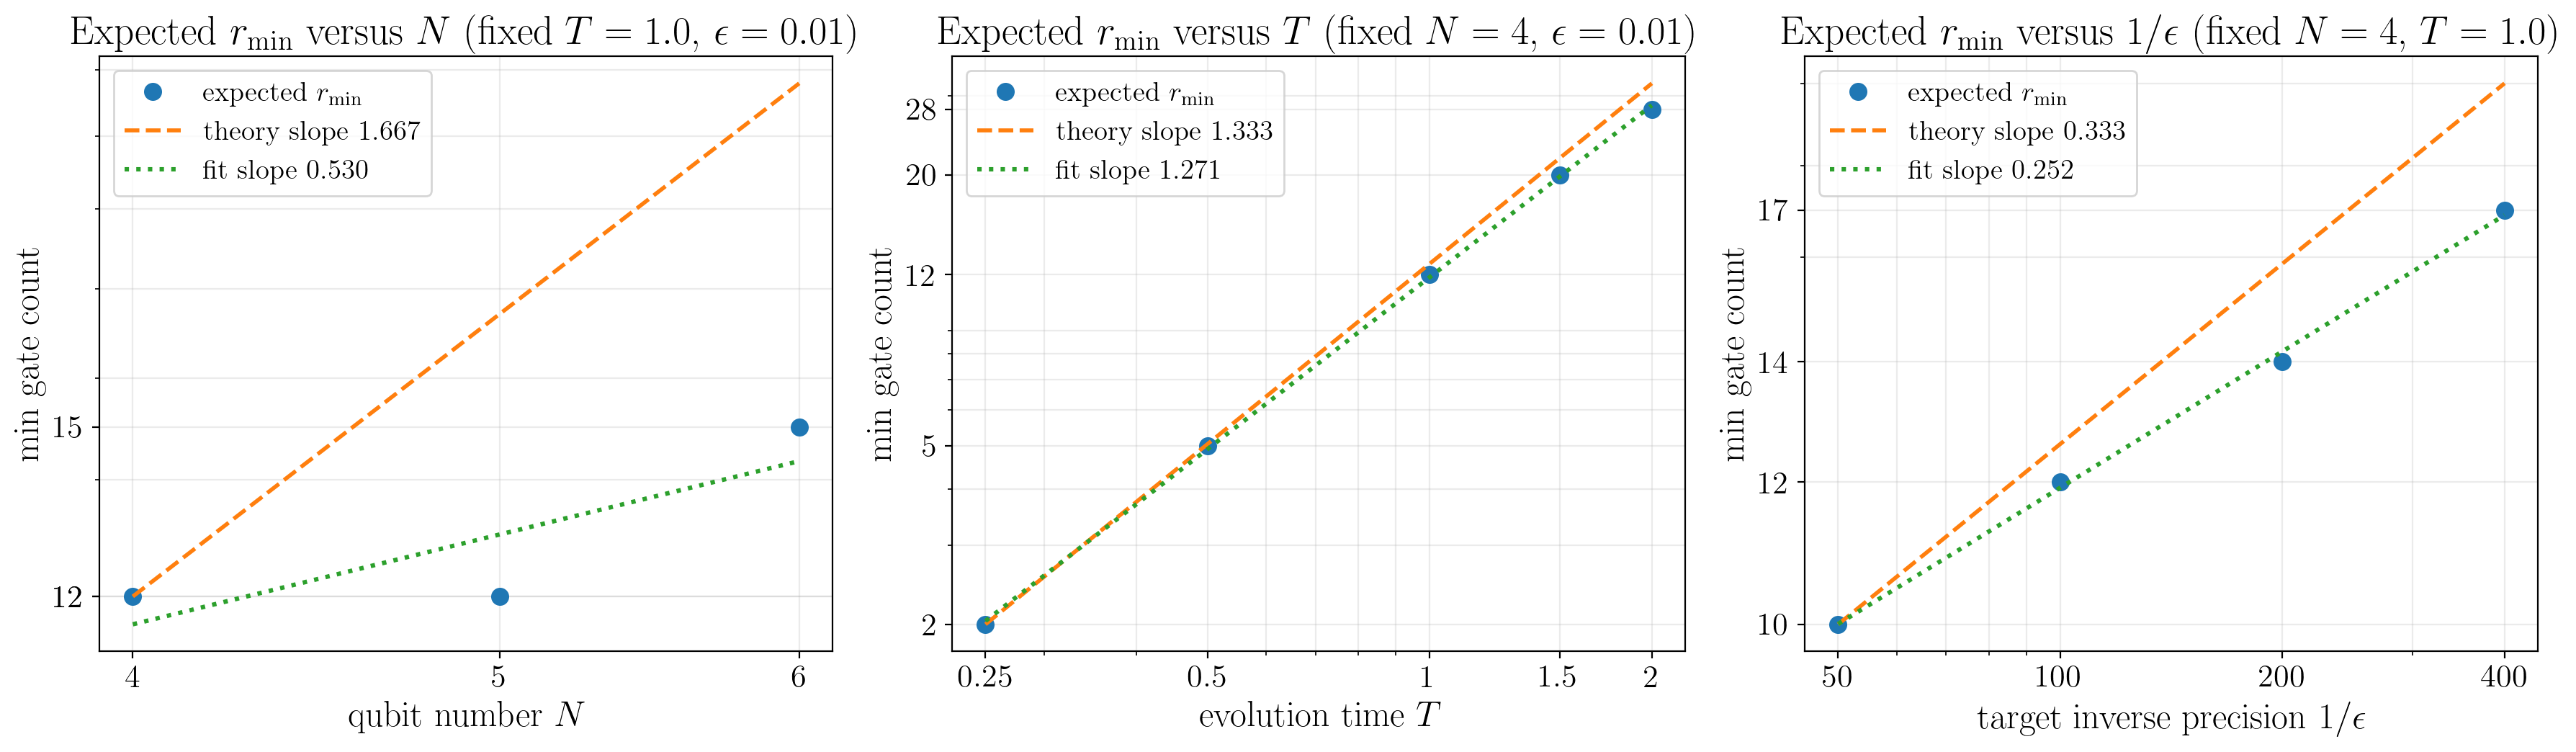

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
slopes_expected = {}
slopes_expected['N'] = plot_expected_panel(
    axes[0],
    series_by_axis['N'],
    'N',
    r'qubit number $N$',
    rf'Expected $r_{{\min}}$ versus $N$ (fixed $T={BASELINE["T"]}$, $\epsilon={BASELINE["epsilon"]}$)',
    THEORY_EXPONENTS['N'],
)
slopes_expected['T'] = plot_expected_panel(
    axes[1],
    series_by_axis['T'],
    'T',
    r'evolution time $T$',
    rf'Expected $r_{{\min}}$ versus $T$ (fixed $N={BASELINE["N"]}$, $\epsilon={BASELINE["epsilon"]}$)',
    THEORY_EXPONENTS['T'],
)
slopes_expected['inv_epsilon'] = plot_expected_panel(
    axes[2],
    series_by_axis['inv_epsilon'],
    'inv_epsilon',
    r'target inverse precision $1/\epsilon$',
    rf'Expected $r_{{\min}}$ versus $1/\epsilon$ (fixed $N={BASELINE["N"]}$, $T={BASELINE["T"]}$)',
    THEORY_EXPONENTS['inv_epsilon'],
)
fig.tight_layout()
if SAVE_PDF:
    fig.savefig(FIG_DIR / 'plot_original_expected_scaling.pdf', bbox_inches='tight')
slopes_expected


{'N': 0.8357580975556854,
 'T': 1.2023183353323976,
 'inv_epsilon': 0.4974825670117644}

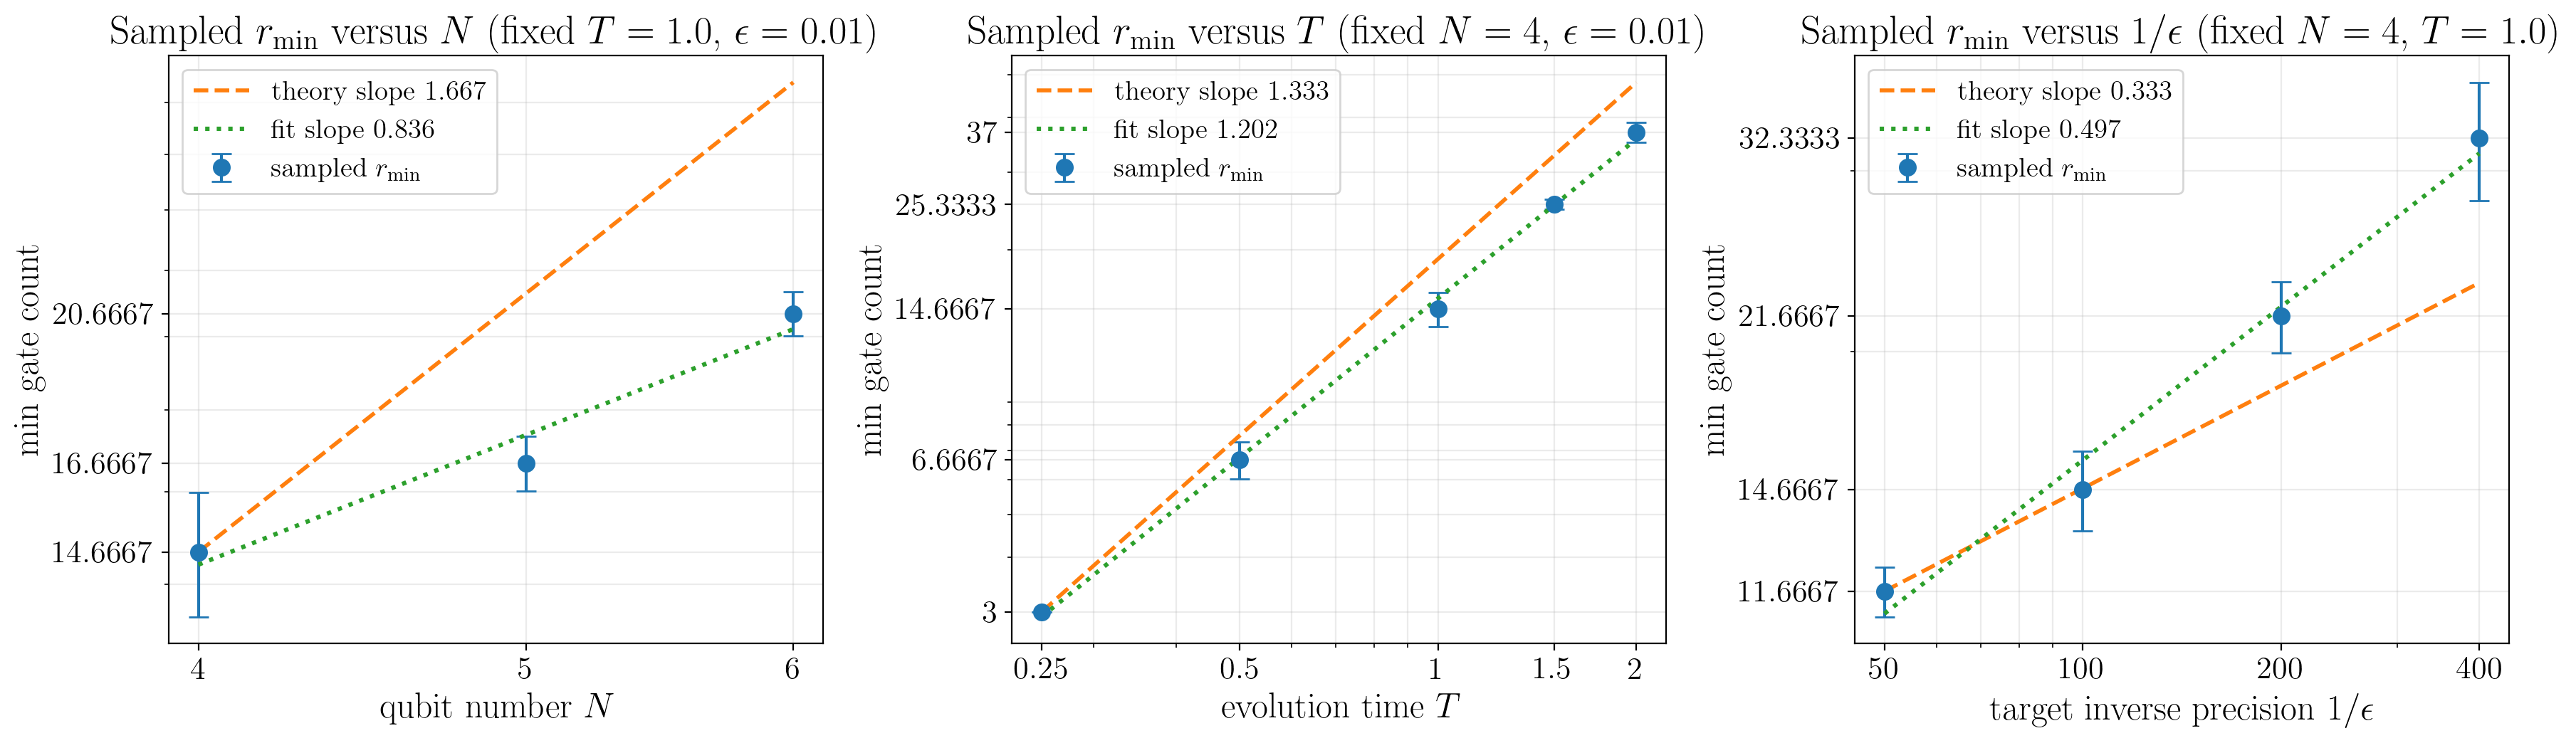

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
slopes_sampled = {}
slopes_sampled['N'] = plot_sampled_panel(
    axes[0],
    series_by_axis['N'],
    'N',
    r'qubit number $N$',
    rf'Sampled $r_{{\min}}$ versus $N$ (fixed $T={BASELINE["T"]}$, $\epsilon={BASELINE["epsilon"]}$)',
    THEORY_EXPONENTS['N'],
)
slopes_sampled['T'] = plot_sampled_panel(
    axes[1],
    series_by_axis['T'],
    'T',
    r'evolution time $T$',
    rf'Sampled $r_{{\min}}$ versus $T$ (fixed $N={BASELINE["N"]}$, $\epsilon={BASELINE["epsilon"]}$)',
    THEORY_EXPONENTS['T'],
)
slopes_sampled['inv_epsilon'] = plot_sampled_panel(
    axes[2],
    series_by_axis['inv_epsilon'],
    'inv_epsilon',
    r'target inverse precision $1/\epsilon$',
    rf'Sampled $r_{{\min}}$ versus $1/\epsilon$ (fixed $N={BASELINE["N"]}$, $T={BASELINE["T"]}$)',
    THEORY_EXPONENTS['inv_epsilon'],
)
fig.tight_layout()
if SAVE_PDF:
    fig.savefig(FIG_DIR / 'plot_original_sampled_scaling.pdf', bbox_inches='tight')
slopes_sampled
